# Track 2 — the data, and the reference model with real numbers

Two halves:

1. **EDA** — what is actually shipped in this repo, and what the panels look like.
2. **The model** — the reference forecaster traced stage by stage, every number reproduced
   from the panels rather than asserted.

Run top to bottom. Everything is offline; no network, no model weights.


## 0 — Setup

Palette and chart chrome are fixed up front so every figure is consistent.

In [1]:
import json, pathlib, tomllib, collections
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

REPO = pathlib.Path.cwd()
if not (REPO / "units").is_dir():          # tolerate running from a subfolder
    REPO = REPO.parent
FIGS = REPO / "nb_figs"; FIGS.mkdir(exist_ok=True)
print("repo:", REPO)

repo: /Users/dew/track2-forecasting-public


In [2]:
# --- palette -------------------------------------------------------------
# Chrome
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"

# Categorical: fixed slot order, never cycled. Slots 1-6.
CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]

# Sequential (one hue, light->dark) for ORDERED dimensions such as tenor.
# Light-mode ordinal floor is step 250, so nothing lighter than #86b6ef.
SEQ6 = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281", "#0d366b"]

# Diverging: two poles + neutral gray midpoint (for correlation, which has polarity).
DIVERGING = LinearSegmentedColormap.from_list("bl_gy_rd", ["#2a78d6", "#f0efec", "#e34948"])

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": BASELINE, "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "text.color": INK, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "font.family": "sans-serif", "font.size": 10,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlepad": 12,
    "lines.linewidth": 2.0, "legend.frameon": False,
    "figure.dpi": 120,
})

def finish(fig, name, note=None, tight=True):
    """Tight layout, optional caption, save, show.

    tight=False for figures using constrained layout -- tight_layout fights a colorbar
    that spans several axes and drops it on top of the plot.
    """
    if note:
        fig.text(0.0, -0.02, note, ha="left", va="top", fontsize=9, color=MUTED)
    if tight:
        fig.tight_layout()
    fig.savefig(FIGS / f"{name}.png", bbox_inches="tight")
    plt.show()

print("palette ready")

palette ready


---
# Part 1 — EDA: what is actually in this repo

Note before starting: the README describes four canonical panels under `data/`
(`data/rates/ust_daily.parquet` and friends). **Those files are not shipped in this public
repo** — `data/` contains only `PROVENANCE.md`. Every panel you can actually read lives inside
a *unit* folder, already truncated at that unit's as-of date. The first cell proves it.

In [3]:
print("data/ contains:", [p.name for p in (REPO/"data").iterdir()])
print()
panels = sorted((REPO/"units").glob("*/*.parquet"))
print(f"{len(panels)} panel files, all inside units/")
print(collections.Counter(p.name for p in panels))

data/ contains: ['PROVENANCE.md']

116 panel files, all inside units/
Counter({'rates_daily.parquet': 51, 'g10_fx_daily.parquet': 40, 'factors_daily.parquet': 16, 'em_transfer_early.parquet': 5, 'macro_monthly.parquet': 4})


### 1.1 — Unit inventory

104 unit folders: 103 practice units plus the worked exemplar.

In [4]:
rows = []
for card_path in sorted((REPO/"units").glob("*/card.toml")):
    c = tomllib.loads(card_path.read_text())
    t, tg = c["task"], c["targets"]
    rows.append({
        "unit_id": t["id"],
        "family": t["id"].split("-")[1],
        "split": t.get("split", "—"),
        "target_type": tg["target_type"],
        "n_assets": len(tg["asset_ids"]),
        "horizons": tuple(tg["horizons"]),
        "asof": c["provenance"]["data_cutoff"],
        "panel": c["metadata"]["asset_panel"],
        "n_docs": c.get("text", {}).get("n_documents", 0),
    })
units = pd.DataFrame(rows)
print(f"{len(units)} unit folders\n")
print(units.groupby(["family", "target_type"]).size().unstack(fill_value=0))
print()
print(units["split"].value_counts().to_string())

104 unit folders

target_type  level  log_return
family                        
EXAMPLE          1           0
F1              21           2
F2              27           0
F3              19           3
F4              20          11

split
validation    71
public-dev    33


In [7]:
df = pd.read_parquet("units/t2-EXAMPLE-ust-curve-1m/rates_daily.parquet")

In [8]:
df

,date,asset,value,panel_id
0,2024-01-02,UST_10Y,4.3104,rates_daily
1,2024-01-02,UST_2Y,4.7704,rates_daily
2,2024-01-02,UST_30Y,4.4456,rates_daily
3,2024-01-02,UST_5Y,4.4017,rates_daily
4,2024-01-03,UST_10Y,4.3122,rates_daily
...,...,...,...,...
511,2024-06-27,UST_5Y,4.3081,rates_daily
512,2024-06-28,UST_10Y,4.2332,rates_daily
513,2024-06-28,UST_2Y,4.7607,rates_daily
514,2024-06-28,UST_30Y,4.4986,rates_daily


The exemplar is the odd one out — it is the only folder with no `forecast_spec.json`, and
it is not counted among the 103 practice units.

In [5]:
units

,unit_id,family,split,target_type,n_assets,horizons,asof,panel,n_docs
0,t2-EXAMPLE-ust-curve-1m,EXAMPLE,public-dev,level,4,"(21,)",2024-06-28,rates_daily,2
1,t2-F1-ai-mom-2024,F1,validation,log_return,1,"(127,)",2024-05-31,factors_daily,7
2,t2-F1-aud-on-hold-2016,F1,validation,level,1,"(126, 189)",2016-11-01,g10_fx_daily,5
3,t2-F1-cad-boc-2017,F1,validation,level,1,"(126, 189)",2017-07-12,g10_fx_daily,5
4,t2-F1-chf-highly-valued-2021,F1,validation,level,1,"(126, 189)",2021-06-17,g10_fx_daily,3
...,...,...,...,...,...,...,...,...,...
99,t2-F4-svb-whiplash-2023,F4,public-dev,level,1,"(21,)",2023-03-08,rates_daily,7
100,t2-F4-taper-warning-2013,F4,validation,level,1,"(63,)",2013-04-30,rates_daily,5
101,t2-F4-ust-downgrade-watch-2011,F4,validation,level,1,"(21,)",2011-07-22,rates_daily,7
102,t2-F4-ust10y-supply-2023,F4,validation,level,1,"(21,)",2023-09-29,rates_daily,5


In [5]:
units["is_example"] = units.unit_id.str.contains("EXAMPLE")
practice = units[~units.is_example]
print(f"practice units : {len(practice)}")
print(f"exemplar       : {units.is_example.sum()}")
print()
print("by target_type (practice only):")
print(practice.target_type.value_counts().to_string())
print()
print("README claims 87 level + 16 log_return =", 87+16)

practice units : 103
exemplar       : 1

by target_type (practice only):
target_type
level         87
log_return    16

README claims 87 level + 16 log_return = 103


In [6]:
units

,unit_id,family,split,target_type,n_assets,horizons,asof,panel,n_docs,is_example
0,t2-EXAMPLE-ust-curve-1m,EXAMPLE,public-dev,level,4,"(21,)",2024-06-28,rates_daily,2,True
1,t2-F1-ai-mom-2024,F1,validation,log_return,1,"(127,)",2024-05-31,factors_daily,7,False
2,t2-F1-aud-on-hold-2016,F1,validation,level,1,"(126, 189)",2016-11-01,g10_fx_daily,5,False
3,t2-F1-cad-boc-2017,F1,validation,level,1,"(126, 189)",2017-07-12,g10_fx_daily,5,False
4,t2-F1-chf-highly-valued-2021,F1,validation,level,1,"(126, 189)",2021-06-17,g10_fx_daily,3,False
...,...,...,...,...,...,...,...,...,...,...
99,t2-F4-svb-whiplash-2023,F4,public-dev,level,1,"(21,)",2023-03-08,rates_daily,7,False
100,t2-F4-taper-warning-2013,F4,validation,level,1,"(63,)",2013-04-30,rates_daily,5,False
101,t2-F4-ust-downgrade-watch-2011,F4,validation,level,1,"(21,)",2011-07-22,rates_daily,7,False
102,t2-F4-ust10y-supply-2023,F4,validation,level,1,"(21,)",2023-09-29,rates_daily,5,False


### 1.2 — Card families

What each family tests, and how many of each ship.

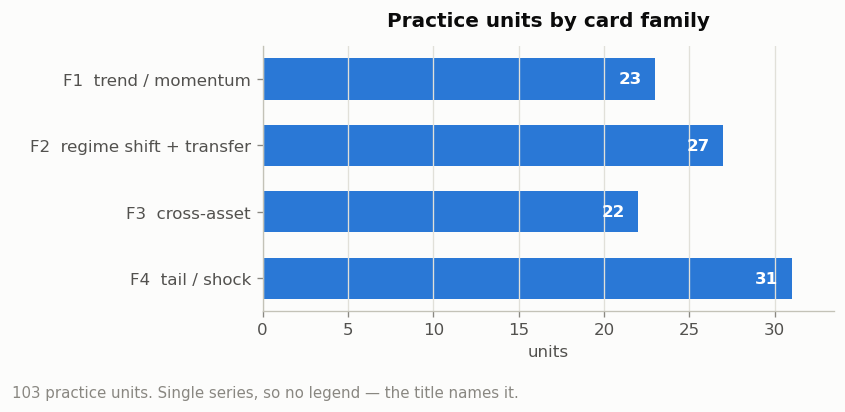

In [7]:
fam_label = {"F1": "F1  trend / momentum", "F2": "F2  regime shift + transfer",
             "F3": "F3  cross-asset", "F4": "F4  tail / shock"}
counts = practice.family.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 3.2))
bars = ax.barh([fam_label[f] for f in counts.index], counts.values,
               color=CAT[0], height=0.62)
for b, v in zip(bars, counts.values):
    ax.text(v - 0.8, b.get_y() + b.get_height()/2, str(v),
            va="center", ha="right", color="#ffffff", fontweight="bold", fontsize=10)
ax.set_title("Practice units by card family")
ax.set_xlabel("units"); ax.invert_yaxis()
ax.grid(axis="y", visible=False); ax.set_xlim(0, counts.max()*1.08)
finish(fig, "01_families", "103 practice units. Single series, so no legend — the title names it.")

### 1.3 — One panel up close

Every panel has the same four columns — `date`, `asset`, `value`, `panel_id`.

**Use a real unit for this, not the exemplar.** The exemplar is a fixture: 4 tenors and 516
rows of synthetic data. A real shipped panel carries all 6 tenors and the full 2000→as-of
history, which is what the README describes.

In [7]:
ex   = REPO/"units/t2-EXAMPLE-ust-curve-1m"      # the fixture
REAL = REPO/"units/t2-F1-hawkish-cut-2024"        # a real rates unit

p = pd.read_parquet(REAL/"rates_daily.parquet")
print("columns :", list(p.columns))
print("dtypes  :", dict(p.dtypes.astype(str)))
print("shape   :", p.shape)
print("assets  :", sorted(p.asset.unique()))
print("dates   :", p.date.min(), "..", p.date.max())
p.head()

columns : ['date', 'asset', 'value', 'panel_id']
dtypes  : {'date': 'object', 'asset': 'str', 'value': 'float64', 'panel_id': 'str'}
shape   : (37470, 4)
assets  : ['UST_10Y', 'UST_20Y', 'UST_2Y', 'UST_30Y', 'UST_5Y', 'UST_7Y']
dates   : 2000-01-03 .. 2024-12-18


,date,asset,value,panel_id
0,2000-01-03,UST_10Y,6.58,rates_daily
1,2000-01-03,UST_20Y,6.94,rates_daily
2,2000-01-03,UST_2Y,6.38,rates_daily
3,2000-01-03,UST_30Y,6.61,rates_daily
4,2000-01-03,UST_5Y,6.50,rates_daily


In [8]:
# The exemplar next to it -- the size difference is the point.
e = pd.read_parquet(ex/"rates_daily.parquet")
pd.DataFrame({
    "rows":    [len(p), len(e)],
    "tenors":  [p.asset.nunique(), e.asset.nunique()],
    "start":   [p.date.min(), e.date.min()],
    "end":     [p.date.max(), e.date.max()],
}, index=["real unit (t2-F1-hawkish-cut-2024)", "exemplar fixture (synthetic)"])

,rows,tenors,start,end
real unit (t2-F1-hawkish-cut-2024),37470,6,2000-01-03,2024-12-18
exemplar fixture (synthetic),516,4,2024-01-02,2024-06-28


### 1.4 — The cutoff rule, verified

Rule 1 of the leakage rules: no panel row is dated after its card's as-of. This is enforced
*before publication*, not at runtime — so it is worth actually checking rather than trusting.
Below, every one of the 116 panels is scanned.

In [9]:
viol = []
for card_path in sorted((REPO/"units").glob("*/card.toml")):
    c = tomllib.loads(card_path.read_text())
    asof = c["provenance"]["data_cutoff"]
    for pq_path in card_path.parent.glob("*.parquet"):
        d = pd.read_parquet(pq_path, columns=["date"])
        mx = d.date.astype(str).str.slice(0, 10).max()
        if mx > asof:
            viol.append((pq_path.name, asof, mx))
print(f"panels scanned : {len(list((REPO/'units').glob('*/*.parquet')))}")
print(f"rows after as-of: {len(viol)}")
print("VIOLATIONS:", viol if viol else "none — the cutoff holds on every shipped panel")

panels scanned : 116
rows after as-of: 0
VIOLATIONS: none — the cutoff holds on every shipped panel


### 1.5 — The UST curve over time

Tenor is an **ordered** dimension, not a set of unrelated categories, so this uses a single-hue
sequential ramp running light→dark with maturity rather than six categorical colors. That makes
the curve's ordering readable directly from the ink.

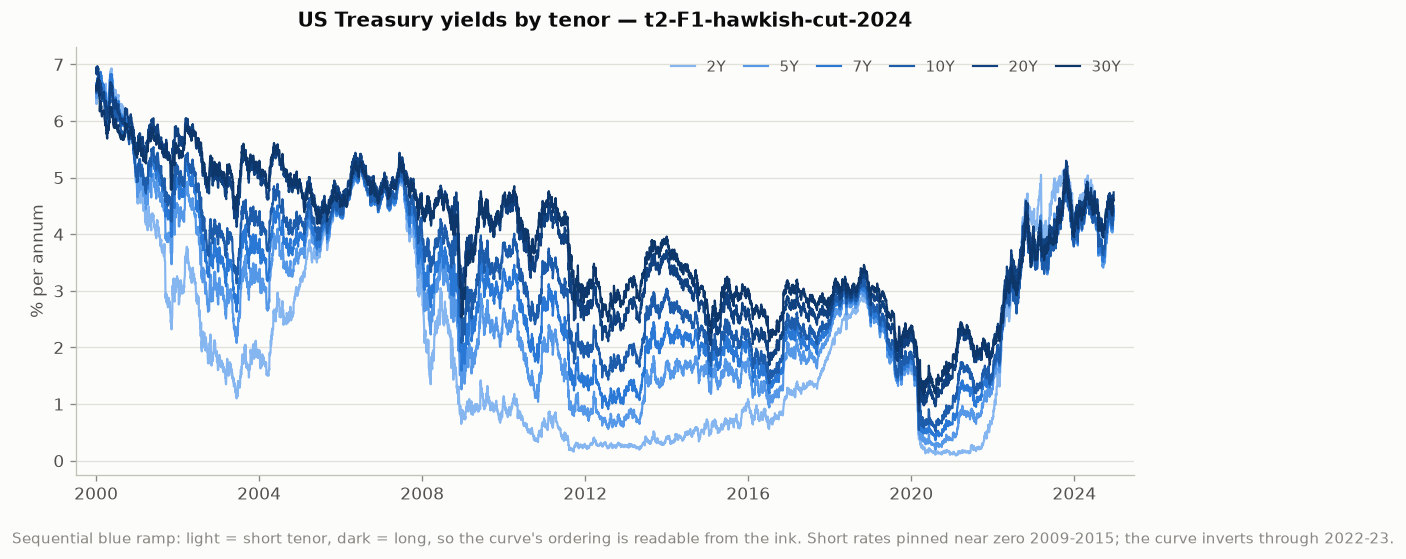

In [10]:
rates = pd.read_parquet(REAL/"rates_daily.parquet")
rates["date"] = pd.to_datetime(rates.date.astype(str).str.slice(0, 10))
order = ["UST_2Y", "UST_5Y", "UST_7Y", "UST_10Y", "UST_20Y", "UST_30Y"]
tenors = [a for a in order if a in set(rates.asset)]

fig, ax = plt.subplots(figsize=(9.5, 4.4))
for a, col in zip(tenors, SEQ6):
    s = rates[rates.asset == a].sort_values("date")
    ax.plot(s.date, s.value, color=col, linewidth=1.3, label=a.replace("UST_", ""))
# Six series -> legend, NOT direct labels. Direct labelling is for <=4; here the tenors
# converge in 2024 and six end-of-line labels collide into an unreadable clump.
ax.set_title(f"US Treasury yields by tenor — {REAL.name}")
ax.set_ylabel("% per annum"); ax.grid(axis="x", visible=False)
ax.margins(x=0.02)
ax.legend(ncol=6, loc="upper right", labelcolor=INK2, fontsize=9,
          columnspacing=1.2, handlelength=1.6)
finish(fig, "02_ust_curve",
       "Sequential blue ramp: light = short tenor, dark = long, so the curve's ordering is readable "
       "from the ink. Short rates pinned near zero 2009-2015; the curve inverts through 2022-23.")

### 1.6 — Factor returns

Factors are **unordered identities**, so this one legitimately uses the categorical palette —
slots assigned in fixed order. Raw daily returns are near-invisible at this scale, so the
chart shows the cumulative log return, which is also exactly the quantity an F1 `log_return`
card asks you to forecast.

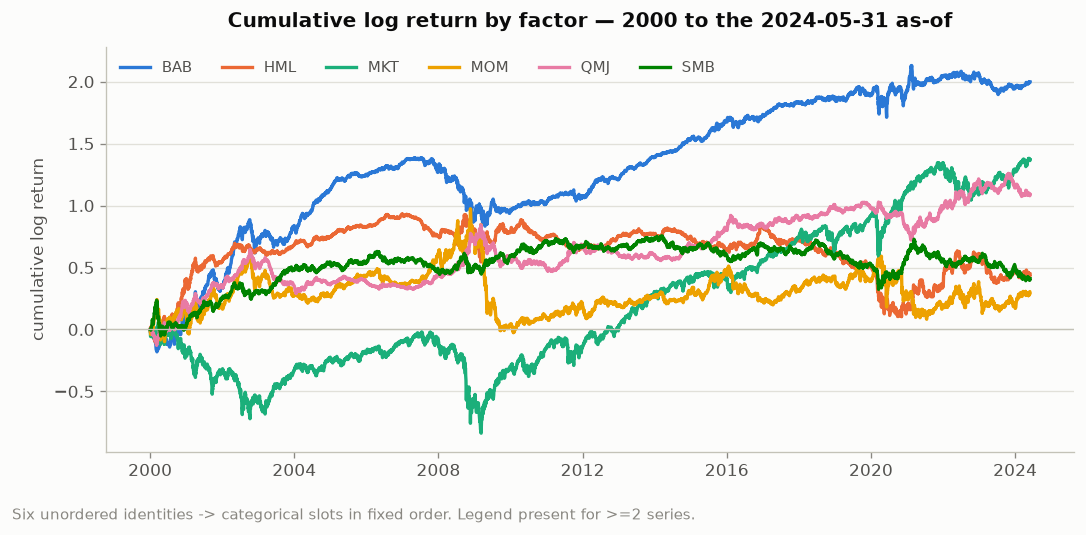

In [11]:
f1 = REPO/"units/t2-F1-ai-mom-2024"
fac = pd.read_parquet(f1/"factors_daily.parquet")
fac["date"] = pd.to_datetime(fac.date.astype(str).str.slice(0, 10))

fig, ax = plt.subplots(figsize=(9, 4.2))
for a, col in zip(sorted(fac.asset.unique()), CAT):
    s = fac[fac.asset == a].sort_values("date")
    ax.plot(s.date, np.log1p(s.value).cumsum(), color=col, label=a)
ax.axhline(0, color=BASELINE, linewidth=0.8)
ax.set_title("Cumulative log return by factor — 2000 to the 2024-05-31 as-of")
ax.set_ylabel("cumulative log return"); ax.grid(axis="x", visible=False)
ax.legend(ncol=6, loc="upper left", labelcolor=INK2, fontsize=9)
finish(fig, "03_factors",
       "Six unordered identities -> categorical slots in fixed order. Legend present for >=2 series.")

### 1.7 — The text corpus

Every unit ships a frozen, dated corpus. The reference model ignores it completely — that gap
is the entire point of Track 2.

In [12]:
docs = sorted((f1/"text").glob("*"))
print(f"{f1.name} corpus — {len(docs)} files")
for d in docs:
    print(f"  {d.name:<52} {d.stat().st_size:>7,} B")
print()
print("corpus size across practice units:")
print(practice.n_docs.describe()[["min", "50%", "max"]].to_string())

t2-F1-ai-mom-2024 corpus — 8 files
  beigebook_202404.txt                                 237,906 B
  bis_bowman_2024-02-02.txt                             23,690 B
  bis_cook_2024-02-22.txt                               21,797 B
  bis_schnabel_2024-02-16.txt                           43,743 B
  bis_ueda_2024-03-06.txt                               13,150 B
  corpus_index.json                                      1,777 B
  fomc_minutes_20240501_released_2024-05-22.txt         47,976 B
  fomc_statement_20240501.txt                            2,827 B

corpus size across practice units:
min     3.0
50%     5.0
max    15.0


In [13]:
idx = json.loads((f1/"text/corpus_index.json").read_text())
print(json.dumps(idx, indent=2)[:900])

{
  "card_id": "t2-F1-ai-mom-2024",
  "asof": "2024-05-31",
  "note": "Frozen dated corpus; every timestamp <= asof (gate g2_cutoff_resource). Minutes/COT timestamps are PUBLIC RELEASE dates, not meeting/report dates.",
  "documents": [
    {
      "doc_id": "bis_bowman_2024-02-02",
      "timestamp": "2024-02-02",
      "source": "BIS central bankers' speeches",
      "doc_type": "cb_speech",
      "file": "bis_bowman_2024-02-02.txt"
    },
    {
      "doc_id": "bis_schnabel_2024-02-16",
      "timestamp": "2024-02-16",
      "source": "BIS central bankers' speeches",
      "doc_type": "cb_speech",
      "file": "bis_schnabel_2024-02-16.txt"
    },
    {
      "doc_id": "bis_cook_2024-02-22",
      "timestamp": "2024-02-22",
      "source": "BIS central bankers' speeches",
      "doc_type": "cb_speech",
      "file": "bis_cook_2024-02-22.txt"
    },
    {
      "doc_id": "bis_ueda_2024


---
# Part 2 — The model, with real numbers

The reference forecaster is a **joint Gaussian random walk**. Its whole job is to reduce the
panel to three numbers per asset — an **anchor**, a **drift**, a **spread** — plus a
**correlation matrix** across assets, then sample from that.

Five stages:

| stage | what it does |
|---|---|
| 1 | read the panel files |
| 2 | pull one asset's history, cut at the as-of |
| 3 | convert the series into **steps** |
| 4 | estimate anchor / drift / sd / correlation |
| 5 | project to the horizon and draw |

Below, each stage is run with the repo's own functions and the numbers checked against the
CLI's own output.

In [14]:
from qfbench2_track_forecasting.cli import _read_panels, _series, _diff_without_gaps, _draw
from qfbench2_track_forecasting.targets import log_return_steps
print("imported the real implementation — nothing here is a reimplementation")

imported the real implementation — nothing here is a reimplementation


## 2.1 — Stages 1–2: panel → one asset's history

The `_read_panels` fallback is visible here: `units/…/panels/` does not exist, so it retries the
parent directory. That is why the README's command works.

In [15]:
card = tomllib.loads((f1/"card.toml").read_text())
ASSET  = card["targets"]["asset_ids"][0]
HORIZ  = card["targets"]["horizons"][0]
ASOF   = card["provenance"]["data_cutoff"]
TARGET = card["targets"]["target_type"]
print(f"card: asset={ASSET}  asof={ASOF}  horizon={HORIZ} BD  target_type={TARGET}")

pan = _read_panels(f1/"panels")               # non-existent dir -> falls back to parent
print("panels loaded:", {k: v.shape for k, v in pan.items()})

hist = _series(pan, ASSET, ASOF)
print(f"\n{ASSET}: {len(hist)} rows, {hist.index[0]} .. {hist.index[-1]}")
hist.tail(3)

card: asset=MOM  asof=2024-05-31  horizon=127 BD  target_type=log_return
panels loaded: {'factors_daily': (37308, 4)}

MOM: 6142 rows, 2000-01-03 .. 2024-05-31


date
2024-05-29    0.0024
2024-05-30   -0.0048
2024-05-31   -0.0065
Name: value, dtype: float64

## 2.2 — Stage 3: the step definition

**This is the branch that matters most.** The panel rows mean different things per
`target_type`, so the step is computed differently:

| `target_type` | step | count |
|---|---|---|
| `level` | first difference of the value | 87 units |
| `log_return` | `log(1 + r)` | 16 units |

Getting this wrong does not make a forecast *worse* — it makes it a **different quantity**, and
gate g2 rejects it.

In [16]:
steps = pd.Series(log_return_steps(hist), index=hist.index).dropna()
compare = pd.DataFrame({
    "panel value r": hist.tail(4),
    "log(1+r)": steps.tail(4),
    "naive diff (WRONG here)": _diff_without_gaps(hist).tail(4),
})
print(f"target_type = {TARGET}  ->  step = log(1 + r)\n")
compare.round(6)

target_type = log_return  ->  step = log(1 + r)



,panel value r,log(1+r),naive diff (WRONG here)
date,,,
2024-05-28,0.0056,0.005584,0.0030
2024-05-29,0.0024,0.002397,-0.0032
2024-05-30,-0.0048,-0.004812,-0.0072
2024-05-31,-0.0065,-0.006521,-0.0017


## 2.3 — Stage 4: the three numbers

For a `log_return` target the anchor is **zero**, not the last observed value. The target *sums*
future log returns; the last observed return belongs to the past, so anchoring on it would
double-count.

In [17]:
anchor = 0.0                    # log_return branch
drift  = steps.mean()
sd     = steps.std()
print(f"anchor      = {anchor}")
print(f"daily drift = {drift:.8f}")
print(f"daily sd    = {sd:.6f}")
print(f"history rows used = {len(steps)}")

anchor      = 0.0
daily drift = 0.00004797
daily sd    = 0.010830
history rows used = 6142


## 2.4 — Stage 5: project to the horizon

Drift scales **linearly** with the horizon; spread scales with **√h**. Standard random-walk
scaling.

In [18]:
centre_h = drift * HORIZ
sd_h     = sd * np.sqrt(HORIZ)
print(f"centre at h = drift * h      = {drift:.8f} * {HORIZ}     = {centre_h:.4f}")
print(f"sd at h     = sd * sqrt(h)   = {sd:.6f} * sqrt({HORIZ}) = {sd_h:.4f}")

centre at h = drift * h      = 0.00004797 * 127     = 0.0061
sd at h     = sd * sqrt(h)   = 0.010830 * sqrt(127) = 0.1220


### Check it against the CLI's own output

The CLI wrote an adjustment ledger into `forecast_rationale.md` when we ran it. If the numbers
above are right, they must match that ledger — and the actual draws must have this spread.

In [19]:
samples, meta = _draw(pan, [ASSET], [HORIZ], ASOF, n_draws=500, seed=0, target_type=TARGET)
drawn = samples[:, 0, 0]
chk = pd.DataFrame({
    "quantity": ["anchor", "daily drift", "daily sd", "centre at h", "sd at h"],
    "computed here": [anchor, drift, sd, centre_h, sd_h],
    "from _draw()":  [meta["last"][ASSET], meta["daily_drift"][ASSET],
                      meta["daily_sd"][ASSET], drift*HORIZ, sd_h],
    "empirical in 500 draws": [np.nan, np.nan, np.nan, drawn.mean(), drawn.std()],
})
chk.round(6)

,quantity,computed here,from _draw(),empirical in 500 draws
0,anchor,0.000000,0.000000,NaN
1,daily drift,0.000048,0.000048,NaN
2,daily sd,0.010830,0.010830,NaN
3,centre at h,0.006092,0.006092,0.002811
4,sd at h,0.122046,0.122046,0.123706


## 2.5 — What the forecast actually looks like

History on the left, the forecast distribution at the horizon on the right. The band is the
model's honest statement of uncertainty — and CRPS scores exactly this: being accurate *and*
appropriately wide.

/var/folders/t8/xyzxk7gn6yj4rb_n35rpd3z40000gn/T/ipykernel_49196/3107226454.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


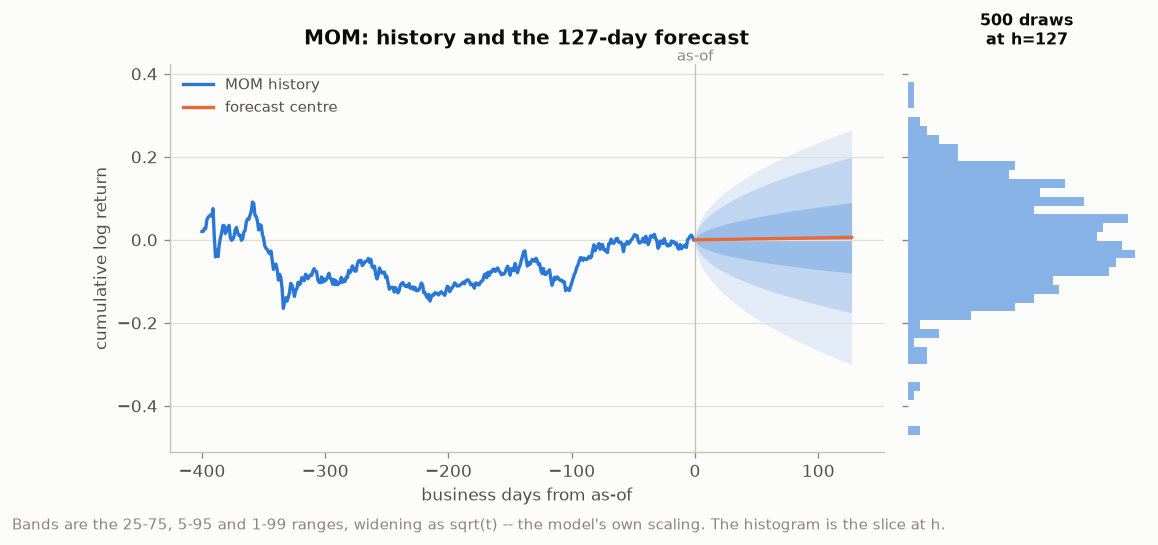

In [20]:
cum = np.log1p(hist).cumsum()
cum = cum - cum.iloc[-1]                      # re-base so the as-of sits at 0
tail_n = 400
x_hist = np.arange(-tail_n, 0)
y_hist = cum.tail(tail_n).to_numpy()

# The band must WIDEN with sqrt(t) -- that is the model's own scaling. Recover the
# standard-normal z for each quantile from the draws, then replay the model forward:
#     centre(t) = drift * t        sd(t) = sd_daily * sqrt(t)
qs = [1, 5, 25, 75, 95, 99]
z = {q: (np.percentile(drawn, q) - centre_h) / sd_h for q in qs}
t = np.linspace(0, HORIZ, 120)
band = {q: drift * t + z[q] * sd * np.sqrt(t) for q in qs}

fig, (ax, axh) = plt.subplots(1, 2, figsize=(10.5, 4.2), sharey=True,
                              gridspec_kw={"width_ratios": [3, 1], "wspace": 0.05})
ax.plot(x_hist, y_hist, color=CAT[0], label=f"{ASSET} history")
ax.axvline(0, color=BASELINE, linewidth=0.8)
ax.text(0, 1.01, "as-of", transform=ax.get_xaxis_transform(),
        color=MUTED, fontsize=9, ha="center")
for (lo, hi), a in zip([(1, 99), (5, 95), (25, 75)], [0.12, 0.18, 0.26]):
    ax.fill_between(t, band[lo], band[hi], color=CAT[0], alpha=a, linewidth=0)
ax.plot(t, drift * t, color=CAT[1], linewidth=2, label="forecast centre")
ax.set_title(f"{ASSET}: history and the {HORIZ}-day forecast")
ax.set_xlabel("business days from as-of"); ax.set_ylabel("cumulative log return")
ax.grid(axis="x", visible=False); ax.legend(loc="upper left", labelcolor=INK2, fontsize=9)

axh.hist(drawn, bins=40, orientation="horizontal", color=CAT[0], alpha=0.55, linewidth=0)
axh.set_title(f"500 draws\nat h={HORIZ}", fontsize=9.5)
axh.grid(axis="y", visible=False); axh.set_xticks([])
for s in ("left", "bottom"): axh.spines[s].set_visible(False)
finish(fig, "04_fan",
       "Bands are the 25-75, 5-95 and 1-99 ranges, widening as sqrt(t) -- the model's own scaling. "
       "The histogram is the slice at h.")

## 2.6 — The joint part, and why it carries 30% of the score

Everything above is one asset. On a multi-asset card the model draws **one shared innovation
vector per draw**, correlated through the Cholesky factor of the historical step correlation.

### First, a warning about the exemplar

The obvious unit to demonstrate this on is the exemplar — it is a 4-tenor curve card. **Do not.**
`run_example.sh` describes its panel as *synthetic*, and the correlation below shows what that
means in practice: its tenors are near-independent, which real Treasuries never are.

Compare it against a real F3 curve card.

In [21]:
def step_corr(unit_dir):
    c = tomllib.loads((unit_dir/"card.toml").read_text())
    assets, asof = c["targets"]["asset_ids"], c["provenance"]["data_cutoff"]
    pan = _read_panels(unit_dir/"panels")
    st = pd.DataFrame({a: _diff_without_gaps(_series(pan, a, asof)) for a in assets}).dropna()
    return st.corr(), assets, c

real = REPO/"units/t2-F3-conundrum-joint-2005"
corr_ex,   ex_assets,   _ = step_corr(ex)
corr_real, real_assets, real_card = step_corr(real)

def offdiag_mean(c):
    v = c.to_numpy(); return v[np.triu_indices_from(v, 1)].mean()

print(f"exemplar (synthetic) mean off-diagonal corr : {offdiag_mean(corr_ex):+.3f}")
print(f"real F3 card         mean off-diagonal corr : {offdiag_mean(corr_real):+.3f}")
corr_real.round(3)

exemplar (synthetic) mean off-diagonal corr : +0.075
real F3 card         mean off-diagonal corr : +0.921


,UST_2Y,UST_5Y,UST_7Y,UST_10Y
UST_2Y,1.000,0.918,0.877,0.837
UST_5Y,0.918,1.000,0.968,0.947
UST_7Y,0.877,0.968,1.000,0.978
UST_10Y,0.837,0.947,0.978,1.000


Correlation has **polarity** — a sign, with zero meaning "nothing" — so it gets a diverging
scale: two poles and a neutral gray midpoint. A sequential ramp would hide the sign.

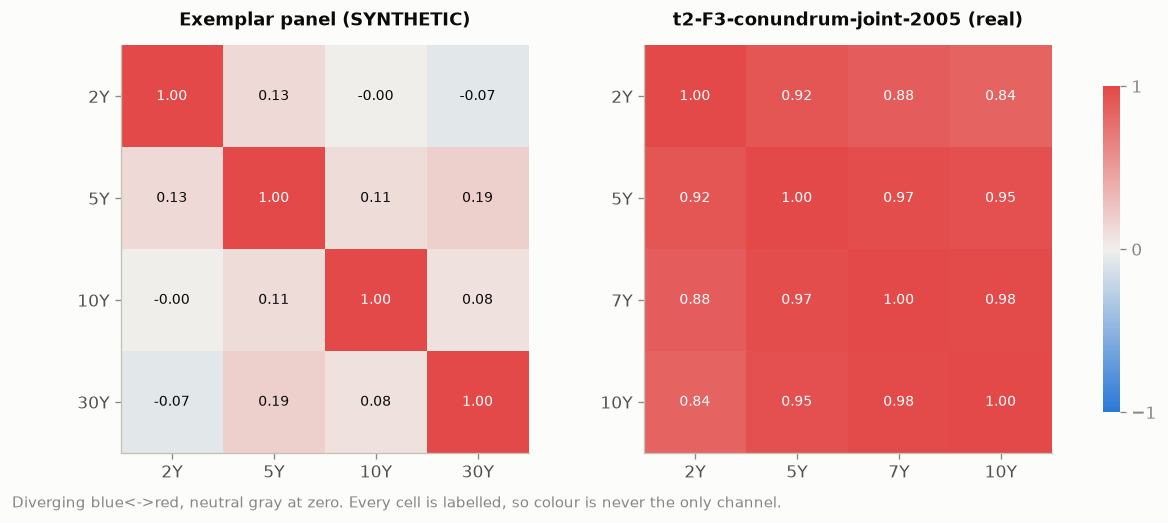

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.0), layout="constrained")
for ax_, (cm, assets, ttl) in zip(axes, [
        (corr_ex, ex_assets, "Exemplar panel (SYNTHETIC)"),
        (corr_real, real_assets, "t2-F3-conundrum-joint-2005 (real)")]):
    im = ax_.imshow(cm.to_numpy(), cmap=DIVERGING, vmin=-1, vmax=1)
    lbl = [a.replace("UST_", "") for a in assets]
    ax_.set_xticks(range(len(lbl)), lbl); ax_.set_yticks(range(len(lbl)), lbl)
    for i in range(len(lbl)):
        for j in range(len(lbl)):
            v = cm.to_numpy()[i, j]
            ax_.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8.5,
                     color="#ffffff" if abs(v) > 0.55 else INK)
    ax_.set_title(ttl, fontsize=10.5); ax_.grid(False)
cb = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, ticks=[-1, 0, 1],
                  location="right", fraction=0.04)
cb.outline.set_visible(False); cb.ax.tick_params(colors=MUTED)
finish(fig, "05_corr",
       "Diverging blue<->red, neutral gray at zero. Every cell is labelled, so colour is never the only channel.",
       tight=False)

### Joint draws vs independent draws

This is the failure the variogram term exists to catch. Both panels below have **identical
marginals** — same mean, same sd per tenor. Only the dependence differs. Run on the real card,
the difference is unmistakable.

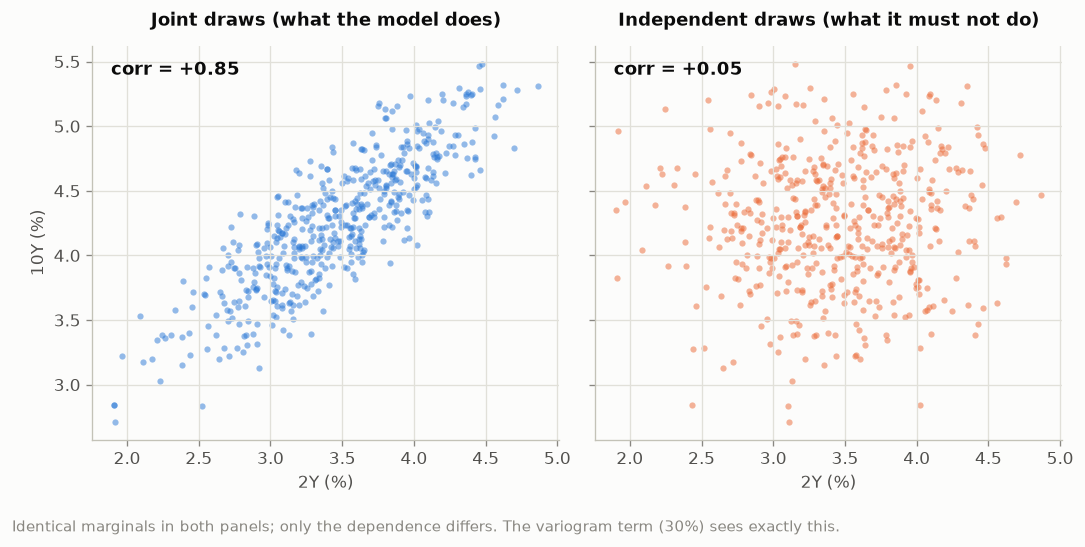

In [23]:
R_ASSETS = real_card["targets"]["asset_ids"]
R_H      = real_card["targets"]["horizons"][0]
R_ASOF   = real_card["provenance"]["data_cutoff"]
R_TARGET = real_card["targets"]["target_type"]
r_pan    = _read_panels(real/"panels")

joint, _ = _draw(r_pan, R_ASSETS, [R_H], R_ASOF, 500, seed=0, target_type=R_TARGET)
i, j = 0, len(R_ASSETS) - 1                        # shortest vs longest tenor
xj, yj = joint[:, i, 0], joint[:, j, 0]
rng = np.random.default_rng(1)
xi, yi = rng.permutation(xj), rng.permutation(yj)  # break dependence, keep marginals

fig, axes = plt.subplots(1, 2, figsize=(9, 4.3), sharex=True, sharey=True)
for ax_, (X, Y, ttl, col) in zip(axes, [
        (xj, yj, "Joint draws (what the model does)", CAT[0]),
        (xi, yi, "Independent draws (what it must not do)", CAT[1])]):
    ax_.scatter(X, Y, s=14, color=col, alpha=0.5, linewidth=0)
    ax_.set_title(ttl, fontsize=10.5)
    ax_.set_xlabel(f"{R_ASSETS[i].replace('UST_','')} (%)")
    ax_.text(0.04, 0.96, f"corr = {np.corrcoef(X, Y)[0,1]:+.2f}", transform=ax_.transAxes,
             va="top", fontsize=10.5, color=INK, fontweight="bold")
axes[0].set_ylabel(f"{R_ASSETS[j].replace('UST_','')} (%)")
finish(fig, "06_joint",
       "Identical marginals in both panels; only the dependence differs. The variogram term (30%) sees exactly this.")

In [24]:
print("marginals are identical -- only the dependence changed:")
pd.DataFrame({
    "joint mean":  [xj.mean(), yj.mean()], "independent mean": [xi.mean(), yi.mean()],
    "joint sd":    [xj.std(),  yj.std()],  "independent sd":   [xi.std(),  yi.std()],
}, index=[R_ASSETS[i], R_ASSETS[j]]).round(4)

marginals are identical -- only the dependence changed:


,joint mean,independent mean,joint sd,independent sd
UST_2Y,3.4462,3.4462,0.5367,0.5367
UST_10Y,4.2441,4.2441,0.5050,0.5050


## 2.7 — What the model does **not** do

The text corpus is opened only to be counted. Seven documents sat next to the F1 card; zero
were read.

That is the floor Track 2 exists to measure agents beating — and the reason a gap between your
agent and this model is the interesting number, while a gap between your agent and the five
`baselines/` scaffolds is **seed noise**, since all five are the same Gaussian random walk under
different fixed seeds.

In [25]:
print("documents available to the F1 card :", len(list((f1/'text').glob('*.txt'))))
print("documents the reference model reads  : 0")
print()
for name in ["theta_arima", "chronos", "timesfm", "lag_llama", "moirai"]:
    src = (REPO/"baselines"/f"{name}.py").read_text()
    print(f"  {name:<12} gaussian-rw-placeholder: {'gaussian-rw-placeholder' in src}")

documents available to the F1 card : 7
documents the reference model reads  : 0

  theta_arima  gaussian-rw-placeholder: True
  chronos      gaussian-rw-placeholder: True
  timesfm      gaussian-rw-placeholder: True
  lag_llama    gaussian-rw-placeholder: True
  moirai       gaussian-rw-placeholder: True


---
## Where this leaves you

- The **cutoff holds** on all 116 shipped panels — verified above, not assumed.
- The model is fully described by **anchor + drift + sd + correlation**; every one of those was
  reproduced here from the panel.
- The `level` / `log_return` branch is the easiest thing to get wrong and the most expensive,
  because it changes *which quantity* you are forecasting.
- **The exemplar's panel is synthetic and its tenors are near-independent.** Do not calibrate
  cross-asset behaviour on it — real F3 curve cards run 0.80–0.92 mean off-diagonal correlation.
  It is a plumbing fixture, not a sample of the data.
- Nothing here reads the text. That is the whole opportunity.

Realized outcomes are sealed, so none of this can tell you how *accurate* a forecast is —
only that it is admissible and that the machinery does what it claims.